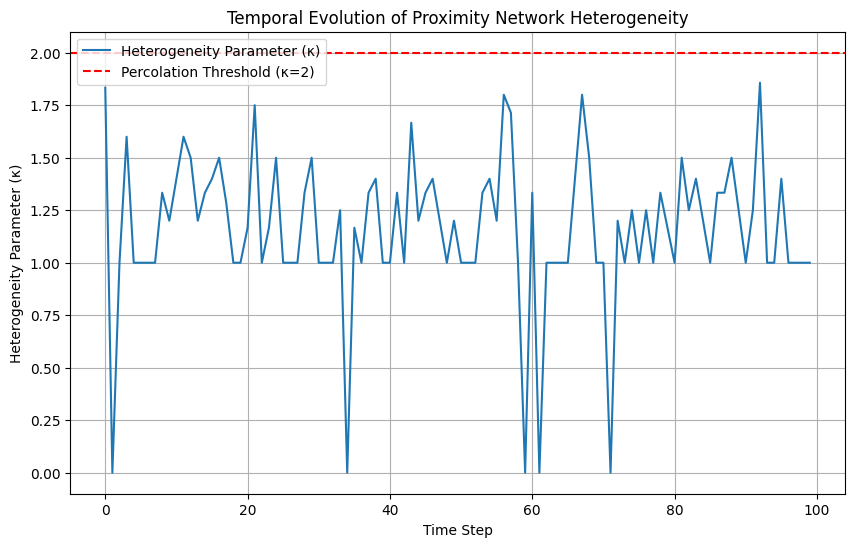

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Example player positions (replace with actual data)
# Simulating 22 players: 11 from Team A and 11 from Team B
np.random.seed(42)  # For reproducibility
num_players = 22
time_steps = 100  # Simulate 100 time steps
field_dimensions = (105, 68)  # Field size in meters (length x width)

# Generate random player positions over time (replace with real data)
player_positions = np.random.rand(time_steps, num_players, 2) * field_dimensions

# Threshold for proximity (meters)
theta = 8.5

# Initialize storage for heterogeneity parameter over time
heterogeneity_params = []

# Process each time step
for t in range(time_steps):
    # Get player positions at current time step
    positions = player_positions[t]

    # Initialize graph for proximity network
    G = nx.Graph()

    # Add players as nodes
    for i in range(num_players):
        G.add_node(i, team='A' if i < num_players // 2 else 'B')

    # Calculate pairwise distances and add edges for close opponents
    for i in range(num_players // 2):  # Team A
        for j in range(num_players // 2, num_players):  # Team B
            dist = np.linalg.norm(positions[i] - positions[j])
            if dist < theta:
                G.add_edge(i, j)

    # Calculate heterogeneity parameter kappa
    degrees = [G.degree(n) for n in G.nodes]
    if len(degrees) > 0:
        k_mean = np.mean(degrees)
        k_squared_mean = np.mean(np.array(degrees) ** 2)
        kappa = k_squared_mean / k_mean if k_mean != 0 else 0
    else:
        kappa = 0

    heterogeneity_params.append(kappa)

# Plot heterogeneity parameter over time
plt.figure(figsize=(10, 6))
plt.plot(range(time_steps), heterogeneity_params, label="Heterogeneity Parameter (κ)")
plt.axhline(y=2, color='r', linestyle='--', label="Percolation Threshold (κ=2)")
plt.xlabel("Time Step")
plt.ylabel("Heterogeneity Parameter (κ)")
plt.title("Temporal Evolution of Proximity Network Heterogeneity")
plt.legend()
plt.grid()
plt.show()


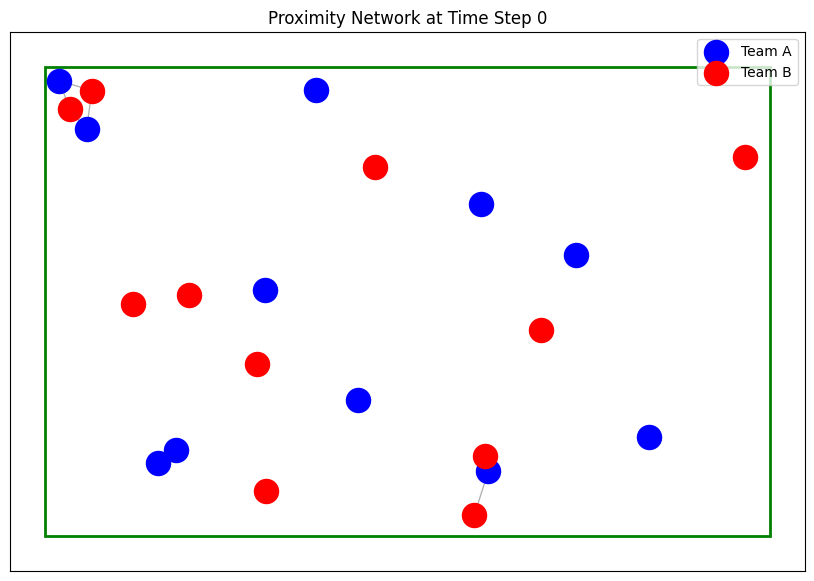

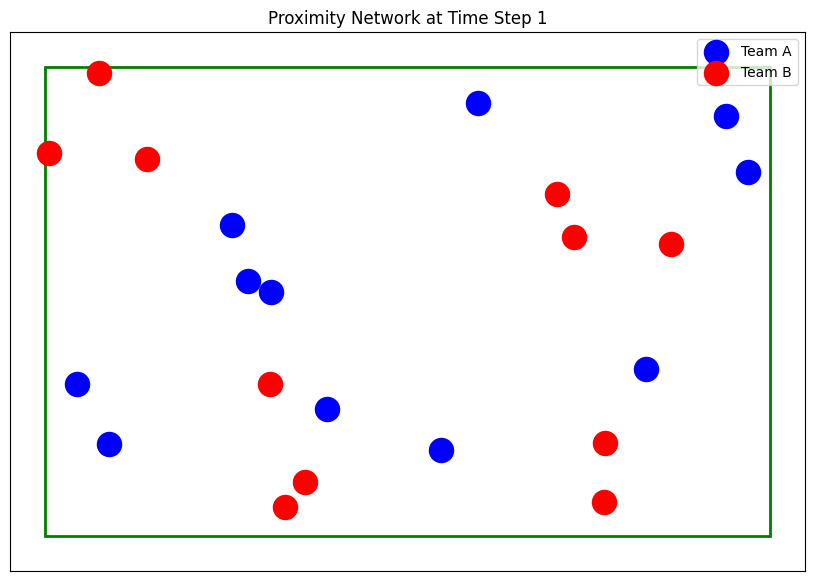

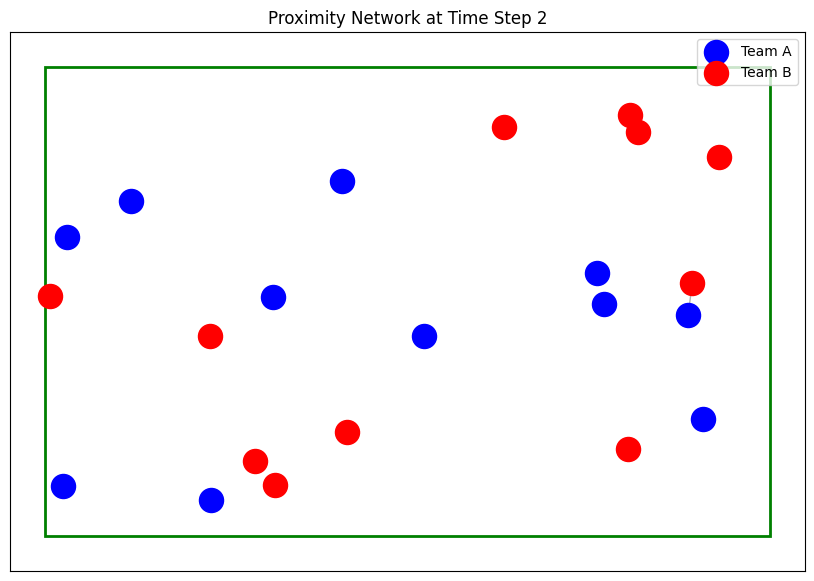

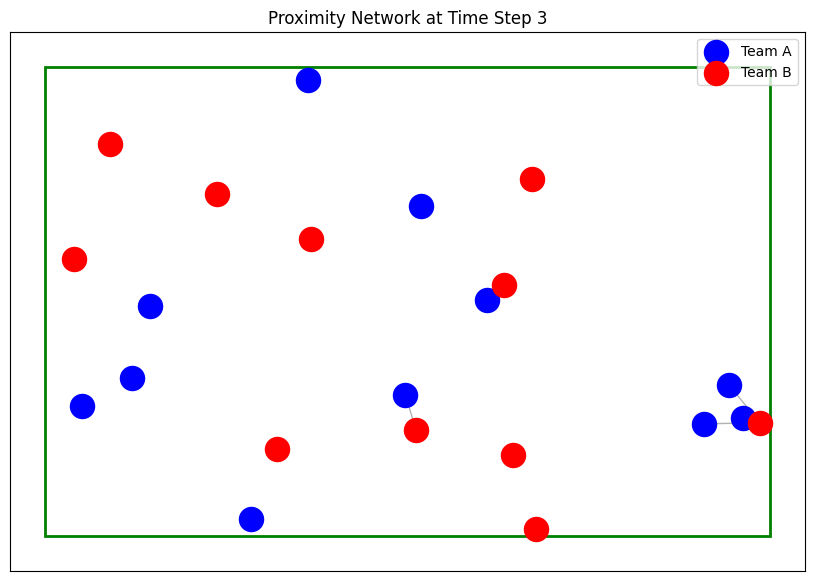

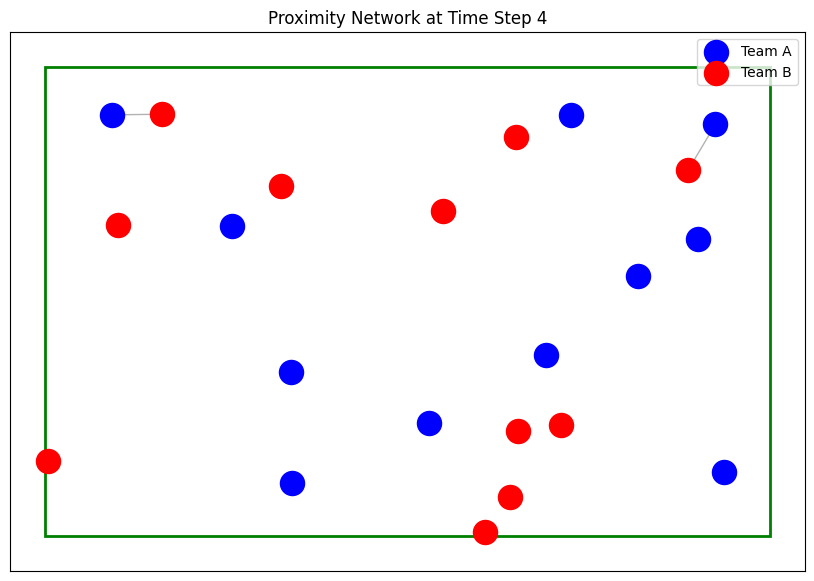

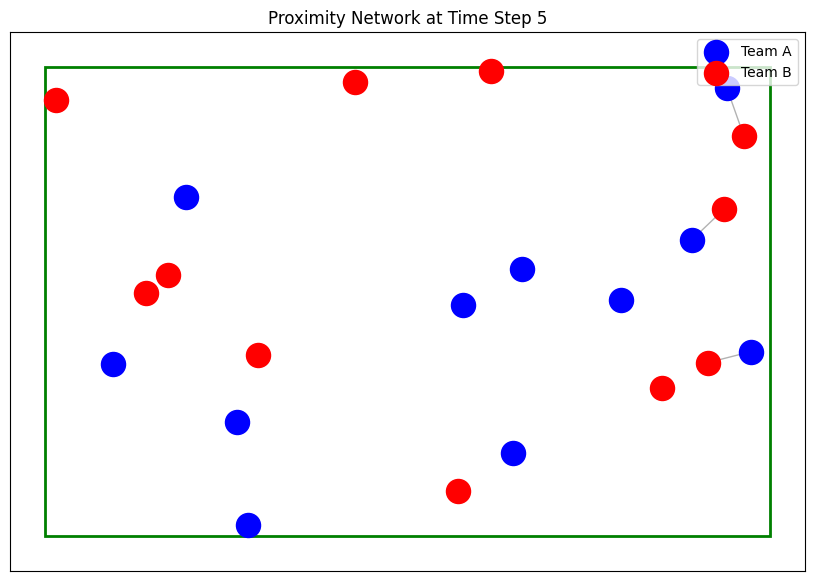

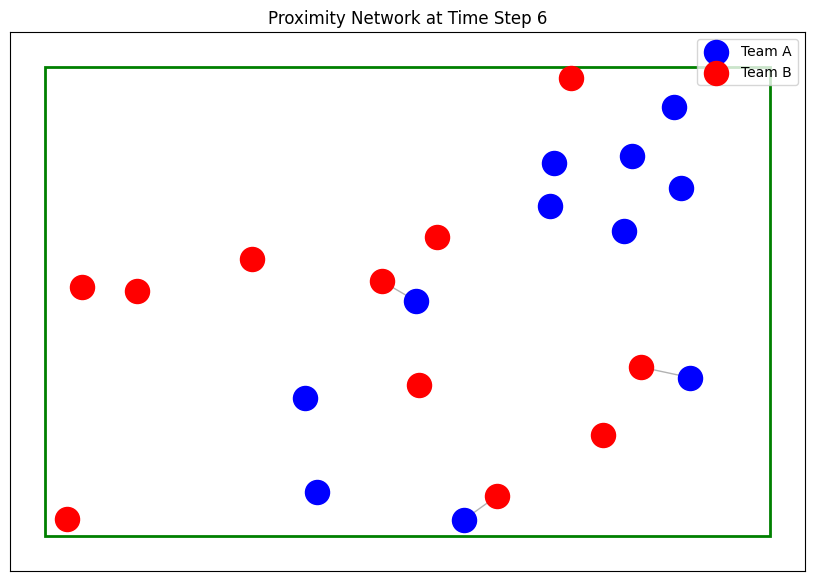

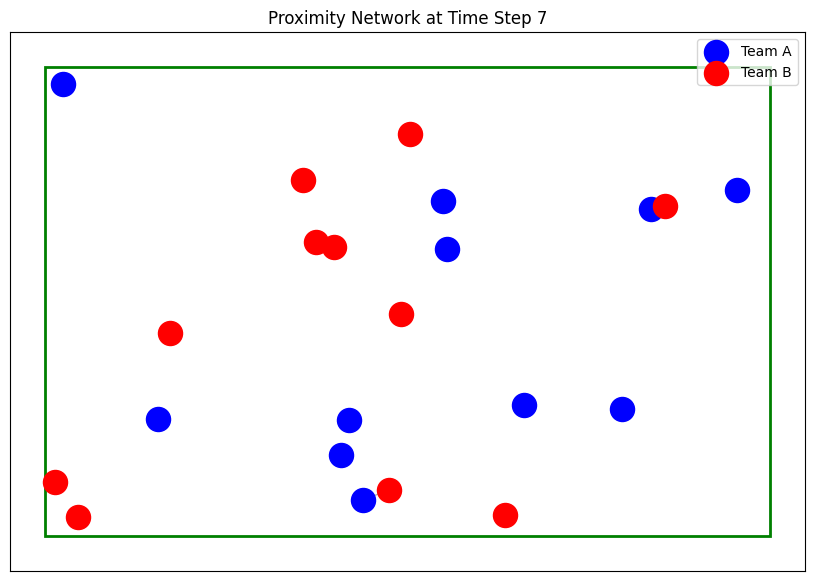

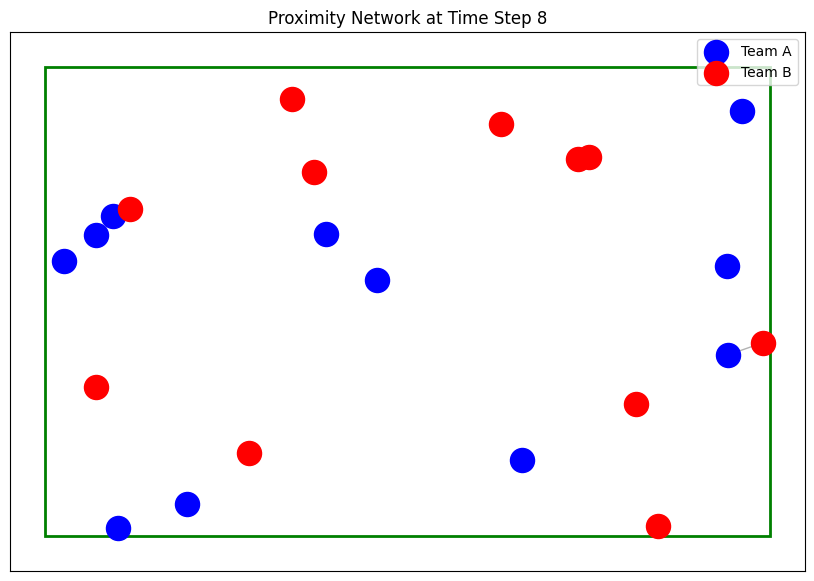

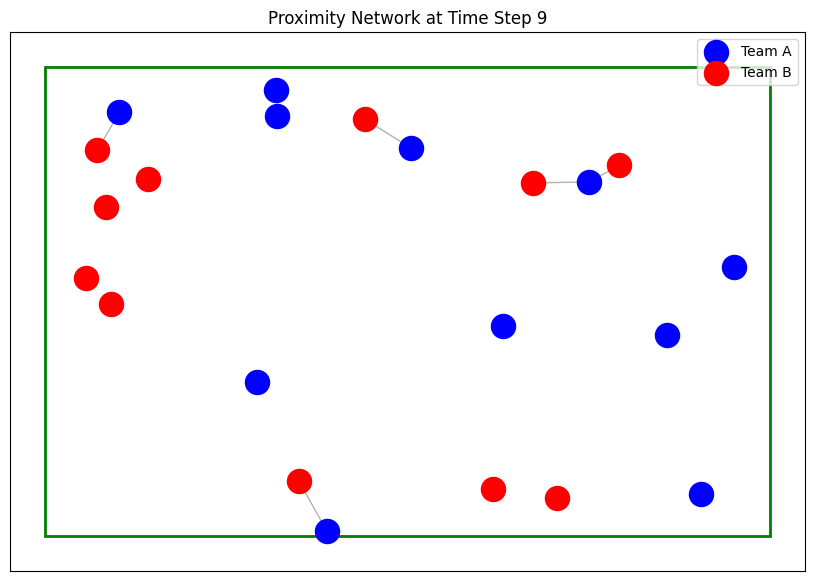

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Simulation parameters
num_players_team_a = 11
num_players_team_b = 11
num_players = num_players_team_a + num_players_team_b
time_steps = 10  # Number of time steps to simulate
field_dimensions = (105, 68)  # Field dimensions in meters (length x width)
theta = 8.5  # Threshold distance for proximity (meters)

# Generate random player positions for each time step (replace with real data)
np.random.seed(42)  # For reproducibility
player_positions = np.random.rand(time_steps, num_players, 2) * field_dimensions

def create_proximity_network(positions, threshold):
    """
    Creates a proximity network using player positions.
    
    :param positions: Array of shape (num_players, 2) with player coordinates
    :param threshold: Distance threshold for creating edges
    :return: NetworkX graph
    """
    G = nx.Graph()
    
    # Add nodes for Team A and Team B
    for i in range(len(positions)):
        team = 'A' if i < num_players_team_a else 'B'
        G.add_node(i, pos=positions[i], team=team)
    
    # Add edges based on proximity
    for i in range(num_players_team_a):  # Team A
        for j in range(num_players_team_a, num_players):  # Team B
            dist = np.linalg.norm(positions[i] - positions[j])
            if dist < threshold:
                G.add_edge(i, j, weight=dist)
    
    return G

def plot_proximity_network(G, time_step, field_dims):
    """
    Plots the proximity network.
    
    :param G: NetworkX graph
    :param time_step: Current time step (for the title)
    :param field_dims: Tuple (length, width) for the field dimensions
    """
    plt.figure(figsize=(12, 7))
    
    # Get node positions and teams
    pos = nx.get_node_attributes(G, 'pos')
    teams = nx.get_node_attributes(G, 'team')
    
    # Draw the field
    plt.gca().add_patch(plt.Rectangle((0, 0), field_dims[0], field_dims[1],
                                      edgecolor='green', fill=False, lw=2))
    
    # Draw nodes
    team_a_nodes = [n for n in G.nodes if teams[n] == 'A']
    team_b_nodes = [n for n in G.nodes if teams[n] == 'B']
    nx.draw_networkx_nodes(G, pos, nodelist=team_a_nodes, node_color='blue', label='Team A')
    nx.draw_networkx_nodes(G, pos, nodelist=team_b_nodes, node_color='red', label='Team B')
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.6)
    
    # Customize plot
    plt.xlim(-5, field_dims[0] + 5)
    plt.ylim(-5, field_dims[1] + 5)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(f"Proximity Network at Time Step {time_step}")
    plt.legend()
    plt.show()

# Simulate and visualize proximity networks over time
for t in range(time_steps):
    positions = player_positions[t]
    proximity_network = create_proximity_network(positions, theta)
    plot_proximity_network(proximity_network, t, field_dimensions)


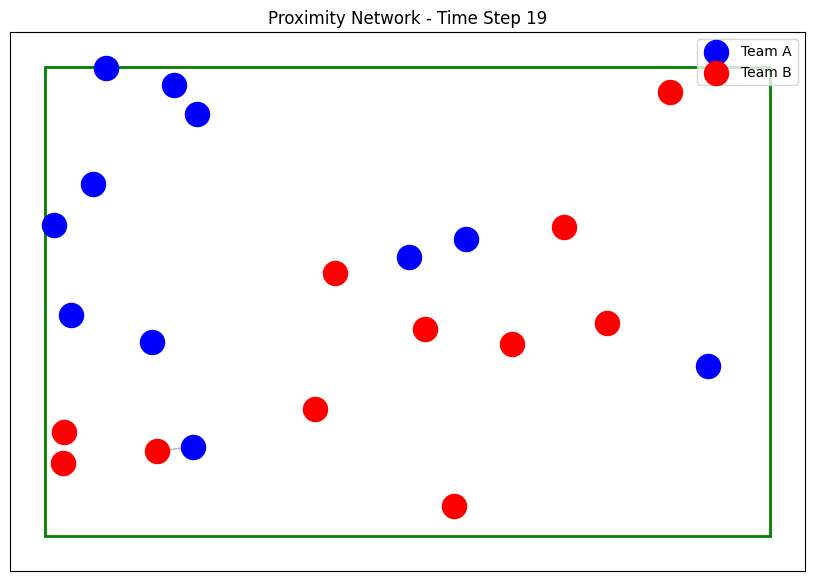

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Simulation parameters
num_players_team_a = 11
num_players_team_b = 11
num_players = num_players_team_a + num_players_team_b
time_steps = 20  # Number of time steps to simulate
field_dimensions = (105, 68)  # Field dimensions in meters (length x width)
theta = 8.5  # Threshold distance for proximity (meters)

# Generate random player positions for each time step (replace with real data)
np.random.seed(42)  # For reproducibility
player_positions = np.random.rand(time_steps, num_players, 2) * field_dimensions

def create_proximity_network(positions, threshold):
    """
    Creates a proximity network using player positions.
    
    :param positions: Array of shape (num_players, 2) with player coordinates
    :param threshold: Distance threshold for creating edges
    :return: NetworkX graph
    """
    G = nx.Graph()
    
    # Add nodes for Team A and Team B
    for i in range(len(positions)):
        team = 'A' if i < num_players_team_a else 'B'
        G.add_node(i, pos=positions[i], team=team)
    
    # Add edges based on proximity
    for i in range(num_players_team_a):  # Team A
        for j in range(num_players_team_a, num_players):  # Team B
            dist = np.linalg.norm(positions[i] - positions[j])
            if dist < threshold:
                G.add_edge(i, j, weight=dist)
    
    return G

def update_frame(t):
    """
    Updates the frame for the animation.
    
    :param t: Current time step
    """
    ax.clear()

    # Draw the field
    ax.add_patch(plt.Rectangle((0, 0), field_dimensions[0], field_dimensions[1],
                                edgecolor='green', fill=False, lw=2))
    
    # Create the proximity network for the current time step
    positions = player_positions[t]
    G = create_proximity_network(positions, theta)
    pos = nx.get_node_attributes(G, 'pos')
    teams = nx.get_node_attributes(G, 'team')
    
    # Draw nodes
    team_a_nodes = [n for n in G.nodes if teams[n] == 'A']
    team_b_nodes = [n for n in G.nodes if teams[n] == 'B']
    nx.draw_networkx_nodes(G, pos, nodelist=team_a_nodes, node_color='blue', label='Team A', ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=team_b_nodes, node_color='red', label='Team B', ax=ax)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.6, ax=ax)
    
    # Customize plot
    ax.set_xlim(-5, field_dimensions[0] + 5)
    ax.set_ylim(-5, field_dimensions[1] + 5)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f"Proximity Network - Time Step {t}")
    ax.legend()

# Initialize the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Create the animation
ani = FuncAnimation(fig, update_frame, frames=time_steps, interval=500)

# Save or show the animation
ani.save("proximity_network_animation.mp4", fps=2, dpi=300)  # Save as MP4
plt.show()  # Show the animation interactively


In [4]:
# Create the animation
ani = FuncAnimation(fig, update_frame, frames=time_steps, interval=500)

# Save the animation
ani.save("proximity_network_animation.mp4", fps=2, dpi=300, codec='libx264')
